NEHA.N.K | 24BAD078
MSE: 207.91715060774996
RMSE: 14.419332529897144
R2 Score: 0.030085923188504338

Regression Coefficients:
                     Coefficient
Parental Education    -1.002130
Test Preparation      -3.817312


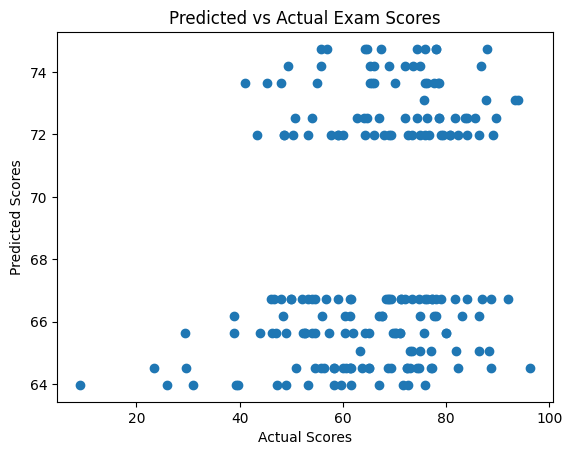

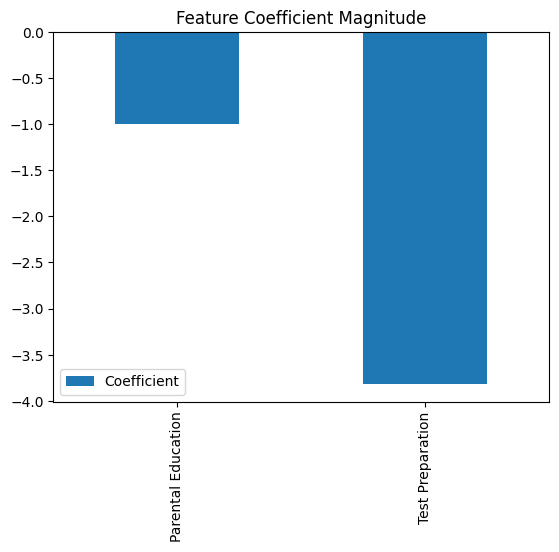

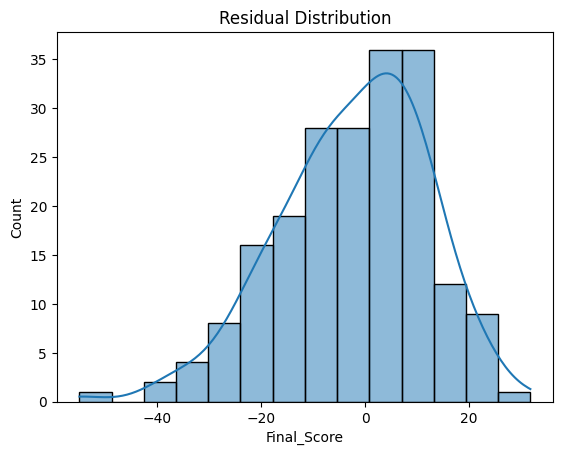

In [3]:
# Multilinear Regression
# NEHA.N.K
# Roll No: 24BAD078

print("NEHA.N.K | 24BAD078")
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Loading dataset
df = pd.read_csv("StudentsPerformance.csv")

# Creating target variable
df['Final_Score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

# Encoding categorical features
le = LabelEncoder()
df['parental level of education'] = le.fit_transform(df['parental level of education'])
df['test preparation course'] = le.fit_transform(df['test preparation course'])

# Selecting features and target
X = df[['parental level of education', 'test preparation course']]
y = df['Final_Score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Multilinear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prediction
y_pred = lr.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Coefficient analysis
coefficients = pd.DataFrame(lr.coef_,
                            ['Parental Education', 'Test Preparation'],
                            columns=['Coefficient'])
print("\nRegression Coefficients:\n", coefficients)

# Ridge and Lasso Regularization
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

# Visualizations
# Predicted vs Actual
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Predicted vs Actual Exam Scores")
plt.show()

# Coefficient comparison
coefficients.plot(kind='bar')
plt.title("Feature Coefficient Magnitude")
plt.show()

# Residual distribution
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


NEHA.N.K | 24BAD078

Polynomial Degree: 2
MSE: 18.41696779601779
RMSE: 4.291499481069267
R2 Score: 0.6391701147013311

Polynomial Degree: 3
MSE: 18.460267222224626
RMSE: 4.296541309265469
R2 Score: 0.6383217814053861

Polynomial Degree: 4
MSE: 18.268226874853184
RMSE: 4.274134634619409
R2 Score: 0.6420842844016577


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


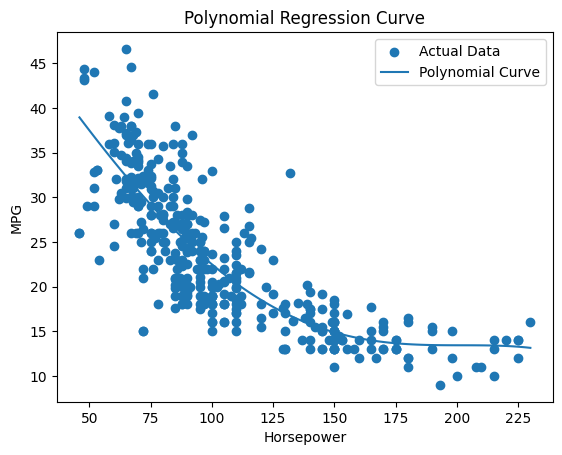

In [4]:
# Polynomial Regression
# NEHA.N.K
# Roll No: 24BAD078
print("NEHA.N.K | 24BAD078")
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Loading dataset
auto = pd.read_csv("auto-mpg.csv")

# Handling missing values
auto.replace('?', np.nan, inplace=True)
auto['horsepower'] = auto['horsepower'].astype(float)
auto.dropna(inplace=True)

# Selecting feature and target
X = auto[['horsepower']]
y = auto['mpg']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Polynomial Regression (Degree 2,3,4)
for degree in [2, 3, 4]:
    print(f"\nPolynomial Degree: {degree}")

    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    scaler = StandardScaler()
    X_poly_train = scaler.fit_transform(X_poly_train)
    X_poly_test = scaler.transform(X_poly_test)

    model = LinearRegression()
    model.fit(X_poly_train, y_train)

    y_pred = model.predict(X_poly_test)

    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

# Ridge Regularization
ridge = Ridge(alpha=1)
ridge.fit(X_poly_train, y_train)

# Visualization
plt.scatter(X, y, label="Actual Data")

X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
X_range_poly = scaler.transform(X_range_poly)

plt.plot(X_range, model.predict(X_range_poly), label="Polynomial Curve")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression Curve")
plt.legend()
plt.show()
